In [1]:
import pandas as pd
import os.path as op
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
from bauer.utils.math import softplus_np

bids_folder = '/Users/mrenke/data/ds-stressrisk'
plot_folder_path = '/Users/mrenke/Desktop/StressRisk/figures/plots/fig_3'

sns.set_context('talk')

#risk_preferences = pd.read_csv(op.join(bids_folder, 'derivatives', 'cogmodels', 'simple_risk_preference.tsv'), index_col=[0, 1], sep='\t')
sns.set_theme('paper', 'white', font='helvetica', font_scale=1.25, palette='tab10')

colors = {'risk-neutral':'k', 'risk-seeking':sns.color_palette('Spectral', 5)[0], 
          'risk-averse':sns.color_palette('Spectral', 5)[-1]}

# MODEL 6

In [5]:
model_n = 6
idata = az.from_netcdf(op.join(bids_folder, 'derivatives', 'cogmodels', f'model-{model_n}_trace.netcdf'))

### Evidence SD

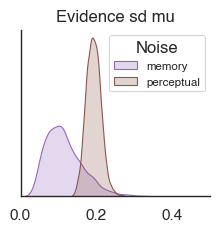

In [16]:
evidence_sd = pd.concat((idata.posterior['memory_noise_sd_mu'].to_dataframe(), (idata.posterior['perceptual_noise_sd_mu'].to_dataframe())), axis=1)
evidence_sd.columns.name = 'parameter'
evidence_sd.index = evidence_sd.index.set_names(['chain','draw','regressor']) # get handel on regressors #'subject',
evidence_sd = evidence_sd.stack().to_frame('value')
evidence_sd['Noise'] = evidence_sd.index.get_level_values('parameter').map({'memory_noise_sd_mu':'memory', 'perceptual_noise_sd_mu':'perceptual'})
evidence_sd['value_softpl'] = softplus_np(evidence_sd['value'])


fac = sns.FacetGrid(evidence_sd.xs('Intercept', 0,'regressor').reset_index(), hue='Noise', palette=sns.color_palette()[4:], aspect=1.1, height=2.5)
fac.map(sns.kdeplot, 'value_softpl', fill=True)
fac.set(xlabel=None, ylabel=None, yticks=[])
plt.title('Evidence sd mu')
# fac.add_legend()
plt.legend(title='Noise',loc='upper right',fontsize='x-small')
plt.xlim([0,0.5])
plt.savefig(op.join(plot_folder_path, 'NLC_model-6_evidence_sd.pdf'), bbox_inches='tight')

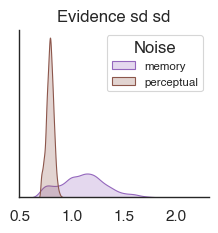

In [15]:
evidence_sd = pd.concat((idata.posterior['memory_noise_sd_sd'].to_dataframe(), (idata.posterior['perceptual_noise_sd_sd'].to_dataframe())), axis=1)
evidence_sd.columns.name = 'parameter'
evidence_sd.index = evidence_sd.index.set_names(['chain','draw','regressor']) # get handel on regressors #'subject',
evidence_sd = evidence_sd.stack().to_frame('value')
evidence_sd['Noise'] = evidence_sd.index.get_level_values('parameter').map({'memory_noise_sd_sd':'memory', 'perceptual_noise_sd_sd':'perceptual'})
evidence_sd['value_softpl'] = softplus_np(evidence_sd['value'])


fac = sns.FacetGrid(evidence_sd.xs('Intercept', 0,'regressor').reset_index(), hue='Noise', palette=sns.color_palette()[4:], aspect=1.1, height=2.5)
fac.map(sns.kdeplot, 'value_softpl', fill=True)
fac.set(xlabel=None, ylabel=None, yticks=[])
plt.title('Evidence sd sd')
# fac.add_legend()
plt.legend(title='Noise',loc='upper right',fontsize='x-small')
#plt.xlim([0,0.5])

### Prior MU

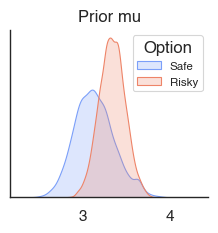

In [31]:
palette = sns.color_palette('coolwarm', 4)
palette = [palette[ix] for ix in [0, 3]]

df_prior_mu = pd.concat((idata.posterior['risky_prior_mu_mu'].to_dataframe(), (idata.posterior['safe_prior_mu_mu'].to_dataframe())), axis=1)
df_prior_mu.columns.name = 'parameter'
df_prior_mu = df_prior_mu.stack().to_frame('value')
df_prior_mu['Option'] = df_prior_mu.index.get_level_values('parameter').map({'risky_prior_mu_mu':'Risky', 'safe_prior_mu_mu':'Safe'})

df_prior_mu['value_norm_scale'] = np.exp(df_prior_mu['value'])

x = 'value' # 'value_norm_scale' #
fac = sns.FacetGrid(df_prior_mu.reset_index(), hue='Option', palette=palette, aspect=1.1, height=2.5, hue_order=['Safe', 'Risky'])
fac.map(sns.kdeplot, x, fill=True)
fac.set(xlabel=None, ylabel=None, yticks=[])
plt.title('Prior mu')
plt.legend(title='Option', loc='upper right',fontsize='x-small')

#plt.savefig(op.join(plot_folder_path, 'NLC_model-6_prior_mu.pdf'), bbox_inches='tight')

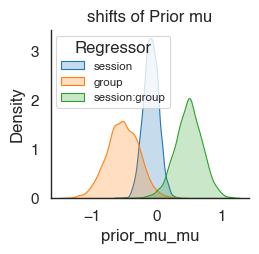

In [27]:
df_prior_mu = idata.posterior['prior_mu_mu'].to_dataframe()

#df_prior_mu.xs('group',0,'prior_mu_regressors') .xs('session:group',0,'prior_mu_regressors')
fac = sns.FacetGrid(df_prior_mu.reset_index(),hue='prior_mu_regressors',  aspect=1.1, height=2.5) #hue='prior_mu_regressors', palette=palette,
fac.map(sns.kdeplot, 'prior_mu_mu', fill=True)
plt.legend(title='Regressor', loc='upper left',fontsize='x-small')
plt.title('shifts of Prior mu')

plt.savefig(op.join(plot_folder_path, 'NLC_model-6_prior_mu_regressors.pdf'), bbox_inches='tight')

# MODEL 1

In [2]:
model_n = 1
idata = az.from_netcdf(op.join(bids_folder, 'derivatives', 'cogmodels', f'model-{model_n}_trace.netcdf'))

## risky/safe prior 

In [66]:
# intercept
palette = sns.color_palette('coolwarm', 4)
palette = [palette[ix] for ix in [0, 3]]

prior_mus= pd.concat((idata.posterior['safe_prior_mu_mu'].to_dataframe(), (idata.posterior['risky_prior_mu_mu'].to_dataframe())), axis=1)
prior_mus.columns.name = 'parameter'
prior_mus.index = prior_mus.index.set_names(['chain','draw','regressor']) 
prior_mus = prior_mus.stack().to_frame('value')
prior_mus['Prior'] = prior_mus.index.get_level_values('parameter').map({'safe_prior_mu_mu':'safe', 'risky_prior_mu_mu':'risky'})

prior_mus = prior_mus.xs('Intercept', 0,'regressor')


In [67]:
np.mean(prior_mus['value'])

3.242028505157819

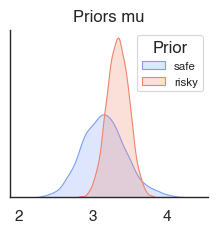

In [68]:
fac = sns.FacetGrid(prior_mus, hue='Prior', palette=palette, aspect=1.1, height=2.5)
fac.map(sns.kdeplot, 'value', fill=True)
fac.set(xlabel=None, ylabel=None, yticks=[])
plt.title('Priors mu')
# fac.add_legend()
plt.legend(title='Prior',loc='upper right',fontsize='x-small')
#plt.xlim([0,0.5])
plt.savefig(op.join(plot_folder_path, f'NLC_model-{model_n}_prior-Intercepts.pdf'), bbox_inches='tight')

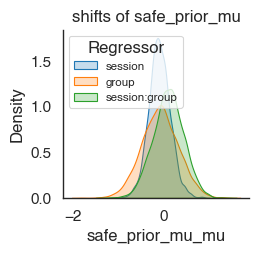

In [29]:
# shift
param_name = 'safe_prior_mu'
df_prior_mu = idata.posterior[f'{param_name}_mu'].to_dataframe()

#df_prior_mu.xs(('group','session','session:group'),axis=0, level=f'{param_name}_regressors')
df_prior_mu = df_prior_mu.reset_index(f'{param_name}_regressors')
df_prior_mu = df_prior_mu[df_prior_mu[f'{param_name}_regressors'] != 'Intercept']

fac = sns.FacetGrid(df_prior_mu.reset_index(),hue=f'{param_name}_regressors',  aspect=1.1, height=2.5) #hue='prior_mu_regressors', palette=palette,
fac.map(sns.kdeplot, f'{param_name}_mu', fill=True)
plt.legend(title='Regressor', loc='upper left',fontsize='x-small')
plt.title(f'shifts of {param_name}')

plt.savefig(op.join(plot_folder_path, f'NLC_model-{model_n}_{param_name}_regressors.pdf'), bbox_inches='tight')

## Evidence sd

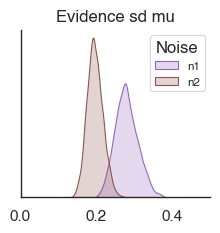

In [48]:
evidence_sd = pd.concat((idata.posterior['n1_evidence_sd_mu'].to_dataframe(), (idata.posterior['n2_evidence_sd_mu'].to_dataframe())), axis=1)

evidence_sd.columns.name = 'parameter'
evidence_sd.index = evidence_sd.index.set_names(['chain','draw','regressor']) # get handel on regressors #'subject',
evidence_sd = evidence_sd.stack().to_frame('value')
evidence_sd['Noise'] = evidence_sd.index.get_level_values('parameter').map({'n1_evidence_sd_mu':'n1', 'n2_evidence_sd_mu':'n2'})
evidence_sd['value_softpl'] = softplus_np(evidence_sd['value'])

fac = sns.FacetGrid(evidence_sd.xs('Intercept', 0,'regressor').reset_index(), hue='Noise', palette=sns.color_palette()[4:], aspect=1.1, height=2.5)
fac.map(sns.kdeplot, 'value_softpl', fill=True)
fac.set(xlabel=None, ylabel=None, yticks=[])
plt.title('Evidence sd mu')
# fac.add_legend()
plt.legend(title='Noise',loc='upper right',fontsize='x-small')
plt.xlim([0,0.5])
plt.savefig(op.join(plot_folder_path, f'NLC_model-{model_n}_evidence_sd.pdf'), bbox_inches='tight')

In [35]:
evidence_sd.xs('Intercept', 0,'regressor') 

value Noise  value_softpl
chain draw parameter                                      
0     0    n1_evidence_sd_mu -1.316187    n1      0.237564
           n2_evidence_sd_mu -1.642622    n2      0.176867
      1    n1_evidence_sd_mu -1.426487    n1      0.215233
           n2_evidence_sd_mu -1.674977    n2      0.171692
      2    n1_evidence_sd_mu -1.333272    n1      0.233975
...                                ...   ...           ...
3     997  n2_evidence_sd_mu -1.650702    n2      0.175561
      998  n1_evidence_sd_mu -1.077784    n1      0.292930
           n2_evidence_sd_mu -1.684644    n2      0.170173
      999  n1_evidence_sd_mu -1.097822    n1      0.287880
           n2_evidence_sd_mu -1.681480    n2      0.170669

[8000 rows x 3 columns]

In [ ]:
print(*list(range(23,43)), sep=',')